# Create 2D Plot 

## Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Functions and Definitions

The following function plots a time-intensity UV/Vis spectrum at a defined wavelength. 

In [ ]:
def plot_2d_spectrum(folder_path, at_wavelength):
    """
    Plots a 2D UV/Vis spectrum from measurement files stored in folder at defined wavelength.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing the UV/Vis measurement files.
    at_wavelength : float
        Defined wavelength in nm.
    """  

    # Definitions
    folder = Path(folder_path) 
    intensity_list = []  # Each intensity at defined wavelength will be stored here.


    # Find out flow speed based on folder name.
    speed = "" 
    for ch in folder.name:
        if ch.isdigit():
            speed = speed + ch


    # Fill 'intensity_list' with intensity at defined wavelength of every file in the folder.
    for file in sorted(folder.glob("*.txt")):

        data = pd.read_csv(file, skiprows=5, sep=";") 

        # Read parameters
        wavelength = data.iloc[1:,0].str.replace(",", ".").astype(float)
        intensity = data.iloc[1:,1].str.replace(",", ".").astype(float)

        idx = (wavelength - at_wavelength).abs().idxmin()  # Searches for wavelength index

        intensity_list.append(intensity.iloc[idx])  # Adds intensity at defined wavelength to 'intensity_list'
    

    intensity_list = intensity_list / max(intensity_list)  # Normalization


    # Plot
    # ----
    # Set fonts
    font1 = {'family':'arial','color':'black','size':14}
    font2 = {'family':'arial','color':'black','size':11}

    # Set title
    plt.title(  
        "UV/Vis 2D Plot" 
        "\n" 
        rf"$\lambda$ = {at_wavelength} nm, $v_{{flow}}$ = {speed} mL/min", 
        fontdict=font1)
    
    # Set axis titles
    plt.xlabel("Time [s]", fontdict=font2)
    plt.ylabel("Intensity [a.u.]", fontdict=font2)

    plt.plot(intensity_list)  # Generate plot before baseline -> looks cleaner 

    # Set baseline
    # The baseline is obtained from the first few 'only water' spectra.
    # Here it's defined as the average value of all intensities in the first fifteenth of the total time. 
    baseline = np.mean(intensity_list[0: (len(intensity_list)//15) ]) 
    plt.axhline(y=baseline, linestyle="--", color = 'r', label="Baseline")

    plt.grid()
    
    plt.show()

## Examples

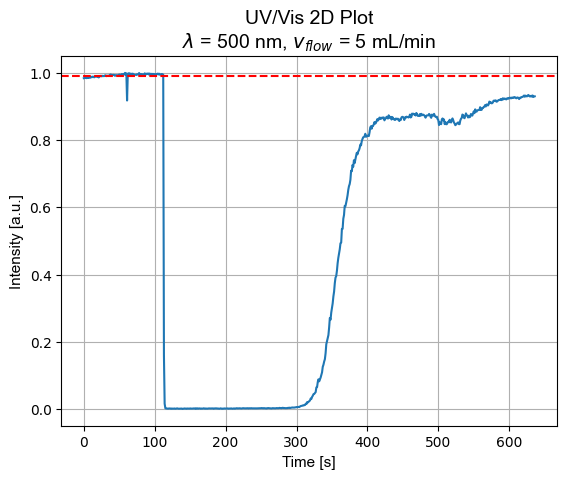

In [ ]:
# Plot spectrum of the fluorescein test series with flow speed of 5 mL/min at 500 nm.
path = "../data/test_series_spectroscopy/spectroscopy_fluorescein_5"
plot_2d_spectrum(path, 500)

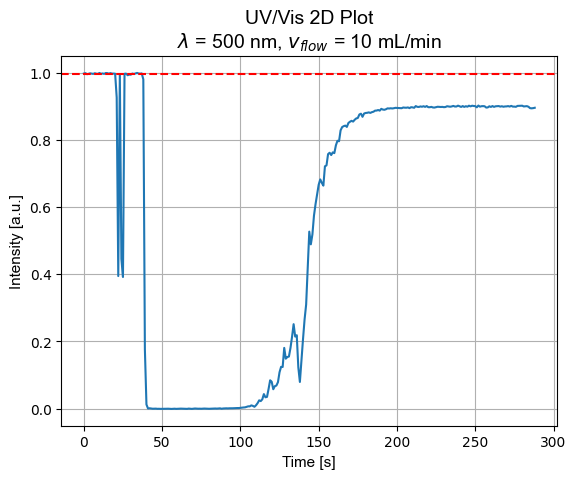

In [ ]:
# Plot spectrum of the motor test series with flow speed of 10 mL/min at 500 nm.
path = "../data/test_series_switch_motor/motor_fluorescein_10b"
plot_2d_spectrum(path, 500)